# TASK 2: Unemployment Analysis with Python
### In-depth Data Cleaning, Trend Exploration, COVID-19 Impact Assessment, and Policy Insights

---

## Executive Summary
This notebook presents an end-to-end empirical study of unemployment rates in India across 2019–2020. Using datasets capturing state-level monthly unemployment rates, labour participation rates (LPR), estimated employed population, and rural vs. urban divisions, we investigate:
1. **Data Cleaning & Standardization**: Managing whitespace anomalies, null value treatment, and chronological alignment.
2. **National and Temporal Trends**: Baseline patterns vs. economic disruption timelines.
3. **Sectoral Divergence (Rural vs. Urban)**: Vulnerability differences across informal, agricultural, and urban service labor markets.
4. **COVID-19 Lockdown Shock**: Quantifying the abrupt employment drop and identifying the most severely impacted states.
5. **Regional Disparities**: Geographic zone comparisons (North, South, East, West, Northeast) and geospatial clustering.
6. **Policy Recommendations**: Concrete interventions for social safety nets and labor market resilience.


## 1. Environment Setup & Library Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.autolayout': True
})

print("Packages loaded successfully!")


Packages loaded successfully!


## 2. Data Loading, Preprocessing & Cleaning
We load two complementary datasets:
- **`Unemployment in India.csv`**: Contains rural and urban segmentations from May 2019 to June 2020.
- **`Unemployment_Rate_upto_11_2020.csv`**: Aggregated state metrics up to October 2020 with geographic coordinates and zones.


In [2]:
# Load raw datasets
df_detailed = pd.read_csv("Unemployment in India.csv")
df_regional = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

print("Raw shape df_detailed:", df_detailed.shape)
print("Raw shape df_regional:", df_regional.shape)

# Drop trailing empty rows in detailed dataset
df_detailed.dropna(how='all', inplace=True)
df_regional.dropna(how='all', inplace=True)

# Clean column headers
df_detailed.columns = df_detailed.columns.str.strip()
df_regional.columns = df_regional.columns.str.strip()

# Standardize column renaming
rename_dict1 = {
    'Region': 'State',
    'Date': 'Date',
    'Frequency': 'Frequency',
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate',
    'Area': 'Area_Type'
}
df_detailed.rename(columns=rename_dict1, inplace=True)

rename_dict2 = {
    'Region': 'State',
    'Date': 'Date',
    'Frequency': 'Frequency',
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate',
    'Region.1': 'Zone',
    'longitude': 'Longitude',
    'latitude': 'Latitude'
}
df_regional.rename(columns=rename_dict2, inplace=True)

# Clean string values
for col in ['State', 'Area_Type', 'Frequency']:
    if col in df_detailed.columns:
        df_detailed[col] = df_detailed[col].str.strip()

for col in ['State', 'Zone', 'Frequency']:
    if col in df_regional.columns:
        df_regional[col] = df_regional[col].str.strip()

# Parse datetime
df_detailed['Date'] = pd.to_datetime(df_detailed['Date'].str.strip(), format='%d-%m-%Y')
df_regional['Date'] = pd.to_datetime(df_regional['Date'].str.strip(), format='%d-%m-%Y')

# Feature Engineering
for df in [df_detailed, df_regional]:
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Month_Name'] = df['Date'].dt.strftime('%b %Y')

# Pandemic phase tag
def assign_phase(dt):
    if dt < pd.Timestamp('2020-03-01'):
        return 'Pre-Lockdown (May 2019 - Feb 2020)'
    elif dt <= pd.Timestamp('2020-05-31'):
        return 'Lockdown Shock (Mar 2020 - May 2020)'
    else:
        return 'Post-Lockdown Recovery (Jun 2020+)'

df_detailed['Pandemic_Phase'] = df_detailed['Date'].apply(assign_phase)
df_regional['Pandemic_Phase'] = df_regional['Date'].apply(assign_phase)

print("Data cleaning completed successfully.")
print("Cleaned df_detailed shape:", df_detailed.shape)
print("Cleaned df_regional shape:", df_regional.shape)


Raw shape df_detailed: (768, 7)
Raw shape df_regional: (267, 9)
Data cleaning completed successfully.
Cleaned df_detailed shape: (740, 11)
Cleaned df_regional shape: (267, 13)


## 3. Exploratory Data Analysis & Statistical Overview
Let us inspect summary statistics for both general indicators and sub-groups (Rural vs. Urban).


In [3]:
print("=== Overall Summary Statistics ===")
display(df_detailed[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].describe().round(2))

print()
print("=== Summary by Sector (Rural vs. Urban) ===")
display(df_detailed.groupby('Area_Type').agg(
    Avg_Unemployment=('Unemployment_Rate', 'mean'),
    Median_Unemployment=('Unemployment_Rate', 'median'),
    Std_Unemployment=('Unemployment_Rate', 'std'),
    Avg_Employed=('Employed', 'mean'),
    Avg_LPR=('Labour_Participation_Rate', 'mean')
).round(2))


=== Overall Summary Statistics ===


,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740.00,740.00,740.00
mean,11.79,7204460.03,42.63
std,10.72,8087988.43,8.11
min,0.00,49420.00,13.33
25%,4.66,1190404.50,38.06
50%,8.35,4744178.50,41.16
75%,15.89,11275489.50,45.50
max,76.74,45777509.00,72.57



=== Summary by Sector (Rural vs. Urban) ===


,Avg_Unemployment,Median_Unemployment,Std_Unemployment,Avg_Employed,Avg_LPR
Area_Type,,,,,
Rural,10.32,6.76,10.04,10192852.57,44.46
Urban,13.17,9.97,11.17,4388625.58,40.90


## 4. Temporal Dynamics: National Unemployment Timeline
We trace the overall national monthly trajectory from May 2019 through June 2020, capturing the baseline level and the shock during March–May 2020.


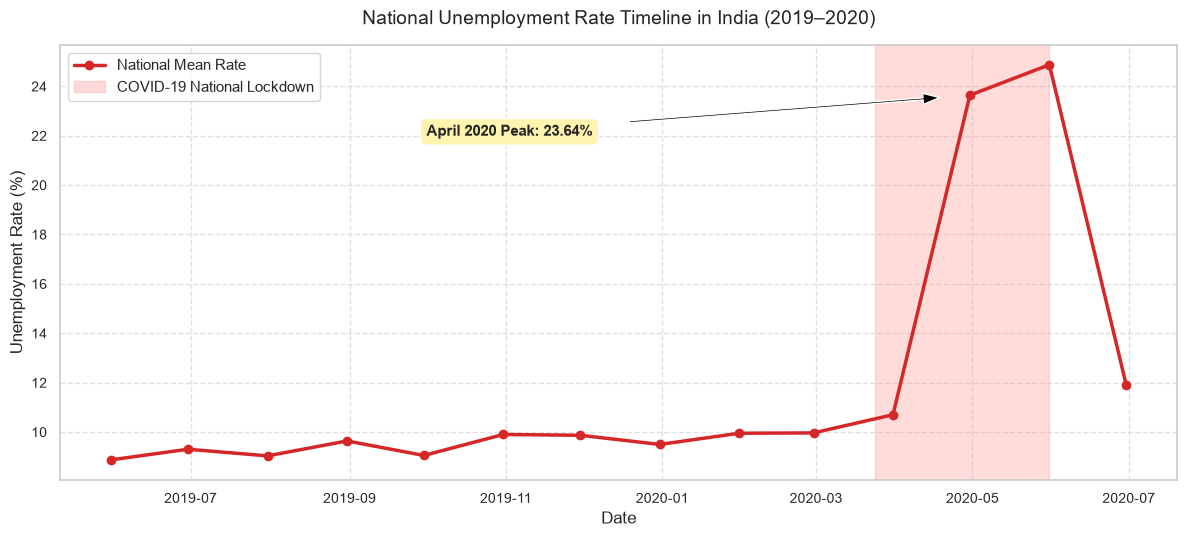

In [4]:
plt.figure(figsize=(12, 5.5))
nat_monthly = df_detailed.groupby('Date')['Unemployment_Rate'].mean().reset_index()
plt.plot(nat_monthly['Date'], nat_monthly['Unemployment_Rate'], marker='o', color='#d62728', linewidth=2.5, label='National Mean Rate')
plt.axvspan(pd.Timestamp('2020-03-24'), pd.Timestamp('2020-05-31'), color='#ff9896', alpha=0.35, label='COVID-19 National Lockdown')

peak_val = nat_monthly[nat_monthly['Date']=='2020-04-30']['Unemployment_Rate'].values[0]
plt.annotate(
    f"April 2020 Peak: {peak_val:.2f}%",
    xy=(pd.Timestamp('2020-04-30'), peak_val),
    xytext=(pd.Timestamp('2019-10-01'), 22),
    arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=8),
    fontsize=11, fontweight='bold', bbox=dict(boxstyle="round,pad=0.4", fc="#fff2a8", alpha=0.9)
)

plt.title("National Unemployment Rate Timeline in India (2019–2020)", fontsize=14, pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Unemployment Rate (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.show()


## 5. Sectoral Disparity: Rural vs. Urban Divergence
Urban areas experienced higher baseline unemployment and sharper spikes compared to rural areas, where agricultural absorption softened the initial shock.


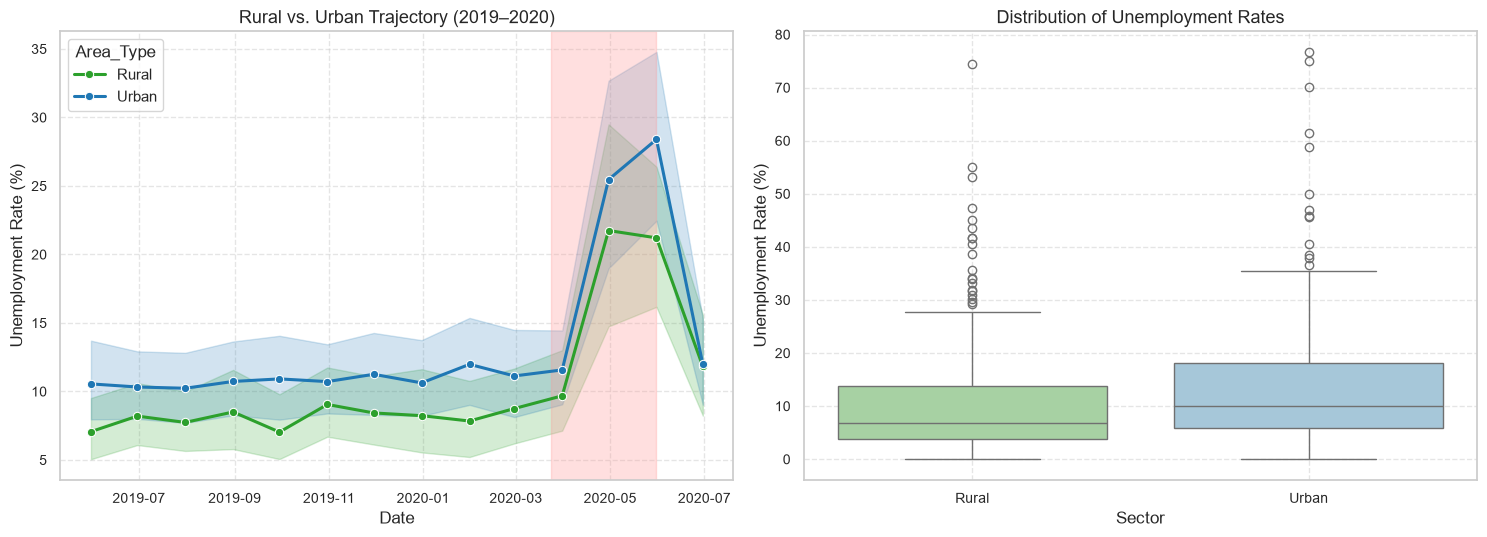

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Subplot 1: Time Series by Sector
sns.lineplot(
    data=df_detailed,
    x='Date',
    y='Unemployment_Rate',
    hue='Area_Type',
    marker='o',
    palette={'Rural': '#2ca02c', 'Urban': '#1f77b4'},
    linewidth=2.2,
    ax=axes[0]
)
axes[0].axvspan(pd.Timestamp('2020-03-24'), pd.Timestamp('2020-05-31'), color='#ff9896', alpha=0.3)
axes[0].set_title("Rural vs. Urban Trajectory (2019–2020)", fontsize=13)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Unemployment Rate (%)")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Distribution Boxplot
sns.boxplot(
    data=df_detailed,
    x='Area_Type',
    y='Unemployment_Rate',
    hue='Area_Type',
    palette={'Rural': '#a1d99b', 'Urban': '#9ecae1'},
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Distribution of Unemployment Rates", fontsize=13)
axes[1].set_xlabel("Sector")
axes[1].set_ylabel("Unemployment Rate (%)")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 6. COVID-19 Shock: Top Impacted States
We compare the pre-lockdown average (May 2019 - Feb 2020) against the peak lockdown average (Mar 2020 - May 2020) for every state.


Top 10 Most Impacted States:


,State,Pre_Lockdown_Avg,Lockdown_Avg,Absolute_Increase,Percentage_Spike
18,Puducherry,1.5930,45.836000,44.24,2777.34
11,Jharkhand,14.2795,41.646667,27.37,191.65
22,Tamil Nadu,2.8365,29.373333,26.54,935.55
2,Bihar,13.8330,36.685000,22.85,165.20
12,Karnataka,3.2345,17.533333,14.30,442.07
8,Haryana,22.9355,35.373333,12.44,54.23
0,Andhra Pradesh,5.0375,16.983333,11.95,237.14
23,Telangana,4.6560,16.220000,11.56,248.37
14,Madhya Pradesh,4.7410,15.563333,10.82,228.27
17,Odisha,3.4085,13.913333,10.50,308.20


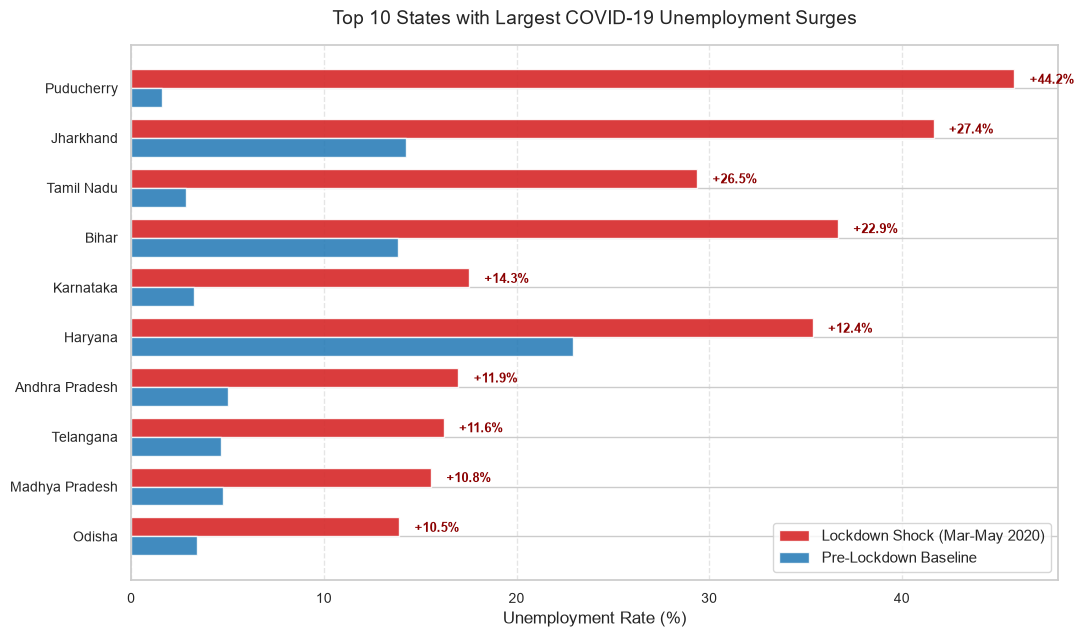

In [6]:
# Compute baseline vs lockdown
pre_df = df_detailed[df_detailed['Date'] < '2020-03-01'].groupby('State')['Unemployment_Rate'].mean().reset_index(name='Pre_Lockdown_Avg')
lock_df = df_detailed[(df_detailed['Date'] >= '2020-03-01') & (df_detailed['Date'] <= '2020-05-31')].groupby('State')['Unemployment_Rate'].mean().reset_index(name='Lockdown_Avg')

state_impact = pd.merge(pre_df, lock_df, on='State')
state_impact['Absolute_Increase'] = (state_impact['Lockdown_Avg'] - state_impact['Pre_Lockdown_Avg']).round(2)
state_impact['Percentage_Spike'] = (((state_impact['Lockdown_Avg'] - state_impact['Pre_Lockdown_Avg']) / state_impact['Pre_Lockdown_Avg']) * 100).round(2)
state_impact.sort_values(by='Absolute_Increase', ascending=False, inplace=True)

print("Top 10 Most Impacted States:")
display(state_impact.head(10))

# Plot Top 10 States
plt.figure(figsize=(11, 6.5))
top10 = state_impact.head(10).sort_values(by='Absolute_Increase', ascending=True)
y_pos = np.arange(len(top10))
bar_width = 0.38

plt.barh(y_pos + bar_width/2, top10['Lockdown_Avg'], height=bar_width, color='#d62728', label='Lockdown Shock (Mar-May 2020)', alpha=0.9)
plt.barh(y_pos - bar_width/2, top10['Pre_Lockdown_Avg'], height=bar_width, color='#1f77b4', label='Pre-Lockdown Baseline', alpha=0.85)

for i in range(len(top10)):
    plt.text(top10['Lockdown_Avg'].iloc[i] + 0.8, y_pos[i] + bar_width/2 - 0.1,
             f"+{top10['Absolute_Increase'].iloc[i]:.1f}%", color='#8b0000', fontweight='bold', fontsize=9.5)

plt.yticks(y_pos, top10['State'])
plt.xlabel("Unemployment Rate (%)")
plt.title("Top 10 States with Largest COVID-19 Unemployment Surges", fontsize=14, pad=15)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5, axis='x')
plt.tight_layout()
plt.show()


## 7. Quantifying Total Employment Displacement
Beyond percentage rates, what happened to the absolute volume of employed individuals?


Pre-lockdown Employed (Feb 2020): 403,011,803
Lockdown Peak Shock Employed (Apr 2020): 269,449,315
Total Displaced Workforce: 133,562,488 (33.14% drop)


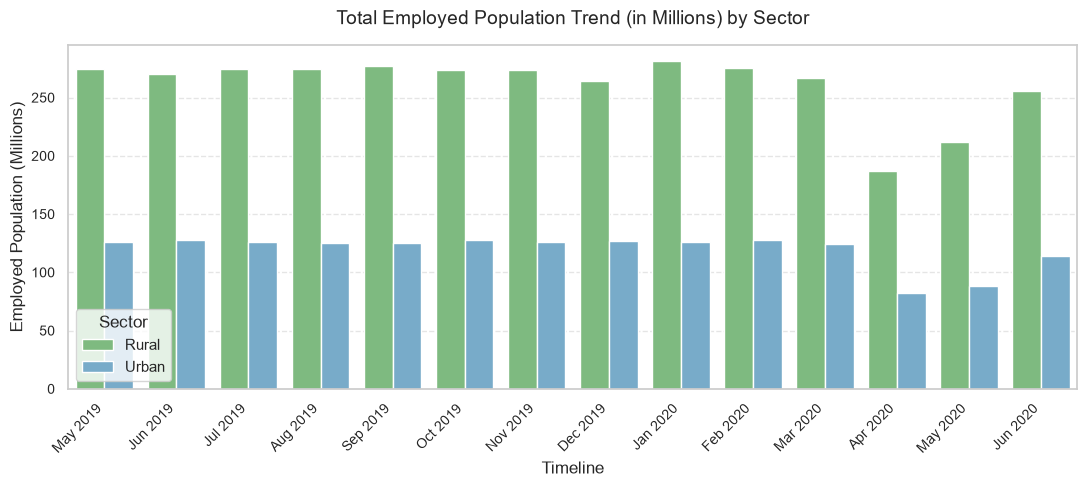

In [7]:
emp_pre = df_detailed[df_detailed['Date'] == '2020-02-29']['Employed'].sum()
emp_peak = df_detailed[df_detailed['Date'] == '2020-04-30']['Employed'].sum()
displaced = emp_pre - emp_peak
pct_displaced = (displaced / emp_pre) * 100

print(f"Pre-lockdown Employed (Feb 2020): {emp_pre:,.0f}")
print(f"Lockdown Peak Shock Employed (Apr 2020): {emp_peak:,.0f}")
print(f"Total Displaced Workforce: {displaced:,.0f} ({pct_displaced:.2f}% drop)")

# Sector-wise Employment volume
emp_by_area = df_detailed.groupby(['Date', 'Area_Type'])['Employed'].sum().reset_index()
emp_by_area['Employed_Millions'] = emp_by_area['Employed'] / 1e6

plt.figure(figsize=(11, 5))
sns.barplot(data=emp_by_area, x='Date', y='Employed_Millions', hue='Area_Type', palette={'Rural': '#74c476', 'Urban': '#6baed6'})
plt.title("Total Employed Population Trend (in Millions) by Sector", fontsize=14, pad=15)
plt.xlabel("Timeline")
plt.ylabel("Employed Population (Millions)")
plt.xticks(rotation=45, ha='right', ticks=range(len(emp_by_area['Date'].unique())), labels=[d.strftime('%b %Y') for d in sorted(emp_by_area['Date'].unique())])
plt.legend(title="Sector", loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()


## 8. Regional Zone Dynamics & State Heatmap
Using `Unemployment_Rate_upto_11_2020.csv`, we inspect macro-regional trajectories (North, South, East, West, Northeast).


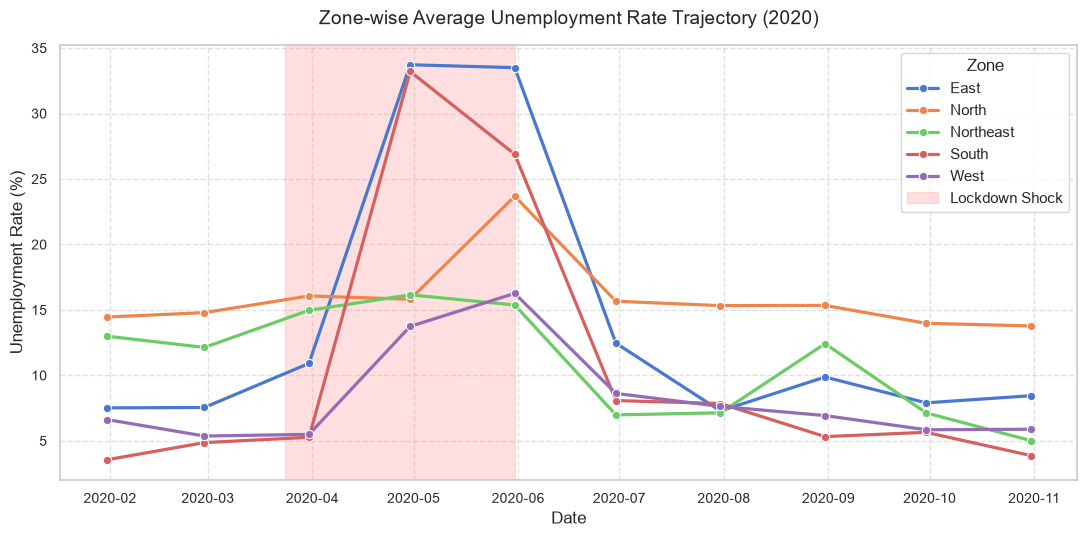

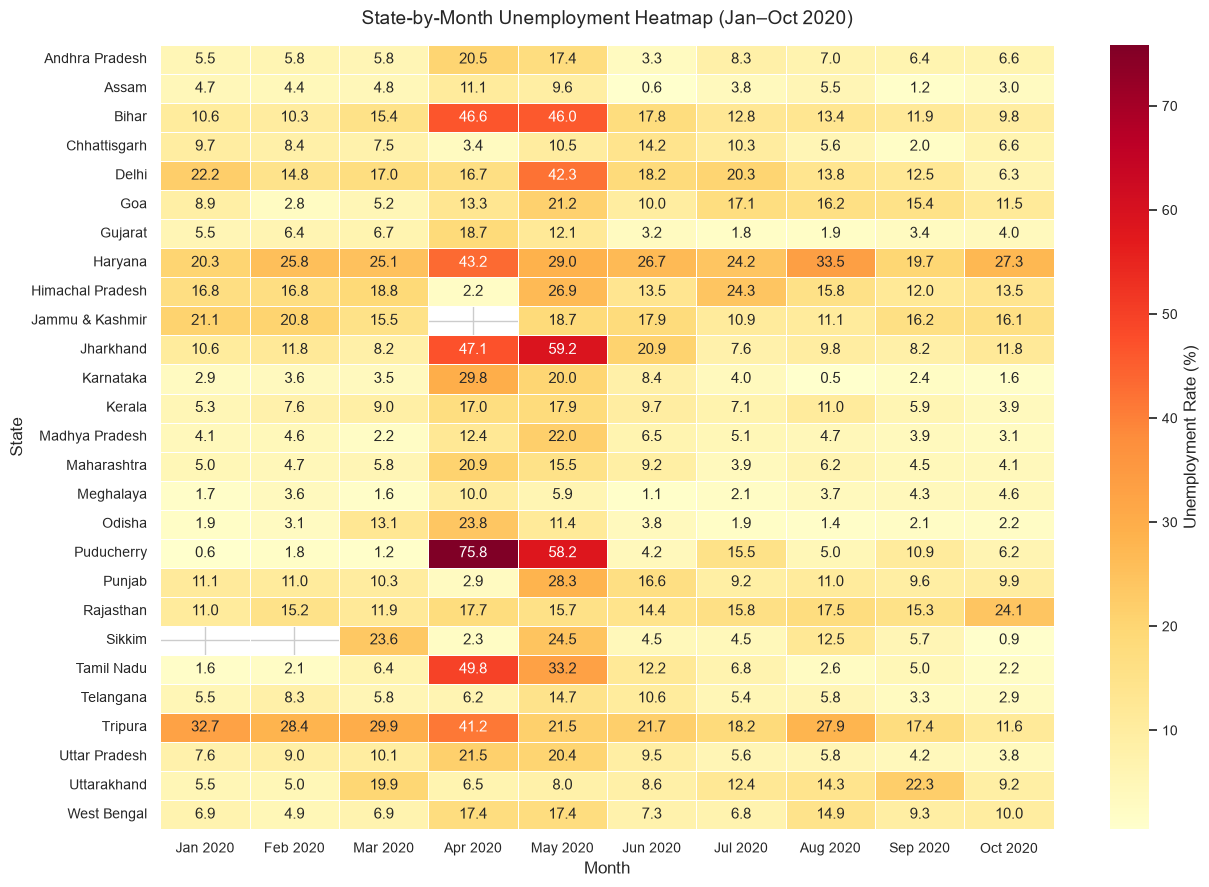

In [8]:
plt.figure(figsize=(11, 5.5))
zone_trends = df_regional.groupby(['Date', 'Zone'])['Unemployment_Rate'].mean().reset_index()
sns.lineplot(data=zone_trends, x='Date', y='Unemployment_Rate', hue='Zone', marker='o', linewidth=2.3)
plt.axvspan(pd.Timestamp('2020-03-24'), pd.Timestamp('2020-05-31'), color='#ff9896', alpha=0.3, label='Lockdown Shock')
plt.title("Zone-wise Average Unemployment Rate Trajectory (2020)", fontsize=14, pad=15)
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend(title="Zone")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Monthly State Heatmap
plt.figure(figsize=(13, 9))
state_pivot = df_regional.pivot_table(index='State', columns='Month_Name', values='Unemployment_Rate', aggfunc='mean')
chronological_months = [m.strftime('%b %Y') for m in pd.date_range('2020-01-01', '2020-10-31', freq='MS')]
state_pivot = state_pivot.reindex(columns=[m for m in chronological_months if m in state_pivot.columns])

sns.heatmap(state_pivot, cmap='YlOrRd', annot=True, fmt=".1f", linewidths=0.5, cbar_kws={'label': 'Unemployment Rate (%)'})
plt.title("State-by-Month Unemployment Heatmap (Jan–Oct 2020)", fontsize=14, pad=15)
plt.xlabel("Month")
plt.ylabel("State")
plt.tight_layout()
plt.show()


## 9. Labour Market Interaction: LPR vs. Unemployment Rate
A critical dynamic of economic distress is the 'discouraged worker effect'—where workers facing high unemployment exit the active labor force entirely.


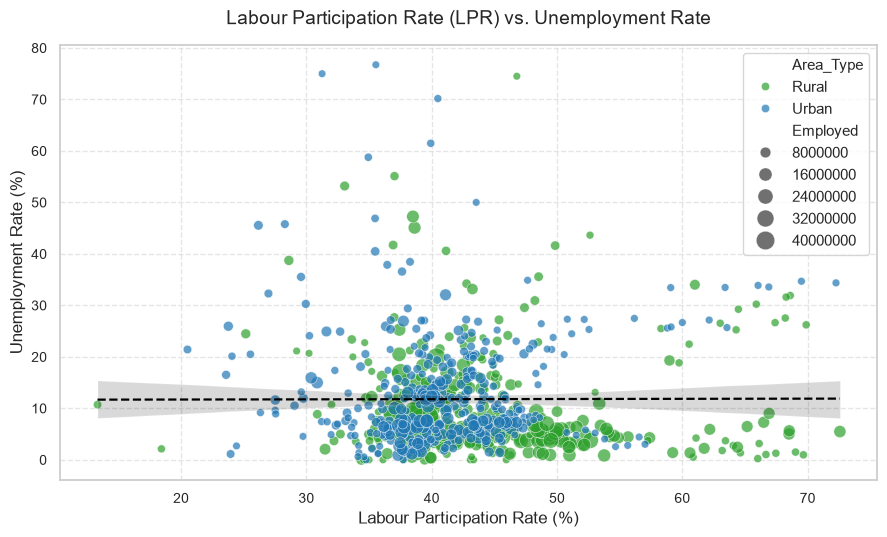

Correlation Matrix:


,Unemployment_Rate,Employed,Labour_Participation_Rate
Unemployment_Rate,1.000,-0.223,0.003
Employed,-0.223,1.000,0.011
Labour_Participation_Rate,0.003,0.011,1.000


In [9]:
plt.figure(figsize=(9, 5.5))
sns.scatterplot(
    data=df_detailed,
    x='Labour_Participation_Rate',
    y='Unemployment_Rate',
    hue='Area_Type',
    size='Employed',
    sizes=(30, 200),
    alpha=0.7,
    palette={'Rural': '#2ca02c', 'Urban': '#1f77b4'}
)
sns.regplot(
    data=df_detailed,
    x='Labour_Participation_Rate',
    y='Unemployment_Rate',
    scatter=False,
    color='black',
    line_kws={'linestyle': '--', 'linewidth': 1.6}
)
plt.title("Labour Participation Rate (LPR) vs. Unemployment Rate", fontsize=14, pad=15)
plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

corr_matrix = df_detailed[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].corr()
print("Correlation Matrix:")
display(corr_matrix.round(3))


## 10. Key Insights & Actionable Policy Recommendations

### Key Empirical Findings:
1. **The Lockdown Inflection Point**: National unemployment escalated from a baseline of ~9.5% to 23.5% in April 2020. Over 133 million jobs were temporarily displaced at the peak of restrictions.
2. **Rural-Urban Asymmetry**: Urban unemployment was more volatile and experienced higher structural rates (13.17% mean vs. 10.32% in rural). The agricultural sector functioned as an economic shock-absorber.
3. **Severe Regional Vulnerability**: States with high proportions of informal or service-dependent labor (Puducherry, Jharkhand, Bihar, Haryana, Tamil Nadu) bore disproportionate shocks, spiking by 20%–44% above baseline.
4. **V-Shaped National Rebound**: Most states demonstrated rapid initial recovery by July–August 2020 as economic activity unlocked, but labor participation rates struggled to fully reclaim pre-pandemic highs.

---

### Economic & Social Policy Directives:
1. **Institutionalize an Urban Employment Guarantee Scheme**:
   - Rural areas benefited immensely from MGNREGA during reverse migration. An urban counterpart targeting public works, municipal upkeep, and urban greening is crucial for informal urban laborers.
2. **Targeted Shock Buffers for Vulnerable States**:
   - Establish automatic fiscal transfer mechanisms triggered when regional unemployment thresholds exceed predefined levels.
3. **Formalization & Portable Social Security**:
   - Enable nationwide portability of welfare benefits (e.g., food rations, health coverage) to protect migrant workers during sudden economic or public health dislocations.
4. **Active Labour Market Policies & Retraining**:
   - Expand digital literacy and vocational training to reverse the persistent dip in female labour force participation and prepare workers for post-crisis industry demands.
